### Deatiled pipeline

In [1]:
%load_ext autoreload
%autoreload 2
from scripts.utils.data_loader import create_configs, load_data
from scripts.utils.preprocessing import lof_outlier_removal
from scripts.utils.post_processing import save_results, compute_fold_shap, plot_shap_summary

from scipy.stats import randint, uniform, loguniform

from sklearn.preprocessing import PowerTransformer

from imblearn import FunctionSampler

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from imblearn.over_sampling import SMOTE, SMOTENC

from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, RandomizedSearchCV, cross_validate

from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

import shap

import os
import numpy as np
import pandas as pd

In [2]:
# Setup experiment configurations
prediction_task = "regression"
case_idx = 8
model_name = "RF"
feature_set = "eGeMAPS_Demographics"
feature_selector_method = "rfe"

N_REPEATS = 3
OUTER_SPLITS = 5
INNER_SPLITS = 5
N_ITER = 3
TOTAL_OUTER_FITS = N_REPEATS * OUTER_SPLITS
ALLOCATED_CPUS = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))

n_dict = {
    "n_repeats": N_REPEATS,
    "outer_splits": OUTER_SPLITS,
    "inner_splits": INNER_SPLITS,
    "n_iter": N_ITER,
    "outer_verbose": 20,
    "inner_verbose": 1,
    "outer_n_jobs": min(ALLOCATED_CPUS, TOTAL_OUTER_FITS),
    "inner_n_jobs": 1
}

config = create_configs(prediction_task, case_idx, model_name,
                        feature_set, feature_selector_method, n_dict)
out_dir = f"../results_tests/{prediction_task}/{model_name}_{feature_selector_method}/array={case_idx}"
config.update({"out_dir": out_dir})
os.makedirs(out_dir, exist_ok=True)

# Load data
X, y, groups, num_cols, cat_cols = load_data(config)

# Define scoring metrics
if config["prediction_task"] == "classification-binary":
    scoring = {
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "average_precision": "average_precision",
        "f1": "f1"
    }
    tuning_scoring = "roc_auc"

else:
    scoring = {
        "neg_root_mean_squared_error": "neg_root_mean_squared_error",
        "neg_mean_absolute_error": "neg_mean_absolute_error",
        "r2": "r2",
    }
    tuning_scoring = "neg_root_mean_squared_error"

# Build pipeline
is_classification = config["prediction_task"] == "classification-binary"

yj_pt = PowerTransformer(method="yeo-johnson", standardize=True)

if config["feature_set"] == "eGeMAPS_Demographics":
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", yj_pt, num_cols),
            ("cat", "passthrough", cat_cols)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    
    cat_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
    oversampler = (
        SMOTENC(categorical_features=cat_indices, random_state=42)
        if is_classification else "passthrough"
    )

else:
    preprocessor = yj_pt
    oversampler = (
        SMOTE(random_state=42) 
        if is_classification else "passthrough"
    )

lof_sampler = FunctionSampler(
    func=lof_outlier_removal,
    kw_args={
        "contamination": 0.05,
        "n_neighbors": 20,
        "algorithm": "auto",
        "metric": "manhattan",
    },
    validate=False,
)

if config["feature_selector_method"] == "rfe":
    feature_selector = (
        RFE(estimator=RandomForestClassifier(n_estimators=25, random_state=42), step = 0.1)
        if is_classification 
        else RFE(estimator=RandomForestRegressor(n_estimators=25, random_state=42), step = 0.1)
    )
elif config["feature_selector_method"] == "passthrough":
        feature_selector = "passthrough"

model = (
    RandomForestClassifier(class_weight=None, n_jobs=1, random_state=42)
    if is_classification
    else RandomForestRegressor(n_jobs=1, random_state=42)
)

steps = [
    ("preprocessor", preprocessor),
    ("outlier_removal", lof_sampler),
    ("oversampler", oversampler),
    ("feature_selector", feature_selector),
    ("model", model),
]

pipeline = ImbPipeline(steps=steps).set_output(transform="pandas")

# Param distributions for RandomizedSearchCV
param_distributions = {}

if feature_selector_method == "rfe":
    param_distributions.update({
        "feature_selector__n_features_to_select": uniform(0.1, 0.9),  # [0.1, 1.0]
    })

if config["prediction_task"] == "classification-binary":
    param_distributions["oversampler__k_neighbors"] = randint(3, 8)  # [3, 7]

param_distributions.update({
    "model__n_estimators": randint(200, 1001),  # [200, 1000]
    "model__max_depth": randint(3, 21),  # [3, 20]
    "model__max_features": ["sqrt", "log2", 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    "model__min_samples_split": uniform(0.05, 0.45),  # [0.05, 0.5]
    "model__min_samples_leaf": uniform(0.01, 0.19),  # [0.01, 0.2]
    "model__ccp_alpha": loguniform(1e-6, 1e-1),
})

# Setup cross-validation
outer_splits = []
if config["prediction_task"] == "classification-binary":
    for i in range(config["n_repeats"]):
        sgkf = StratifiedGroupKFold(
            n_splits=config["outer_splits"],
            shuffle=True,
            random_state=42+i
        )
        outer_splits.extend(list(sgkf.split(X, y, groups)))
    
    inner_cv = StratifiedGroupKFold(
        n_splits=config["inner_splits"],
        shuffle=True,
        random_state=42
    )

else:
    for i in range(config["n_repeats"]):
        gkf = GroupKFold(
            n_splits=config["outer_splits"],
            shuffle=True,
            random_state=42+i
        )
        outer_splits.extend(list(gkf.split(X, y, groups)))
    
    inner_cv = GroupKFold(
        n_splits=config["inner_splits"],
        shuffle=True,
        random_state=42
    )

# Setup hyperparameter tuning
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=config["n_iter"],
    scoring=tuning_scoring,
    n_jobs=config["inner_n_jobs"],
    cv=inner_cv,
    verbose=config["inner_verbose"],
    random_state=42,
    refit=True,
    error_score='raise'
)

# Execute nested cross-validation
results = cross_validate(
    search,
    X=X,
    y=y,
    params={'groups': groups},
    cv=outer_splits,
    scoring=scoring,
    return_estimator=True,
    n_jobs=config["outer_n_jobs"],
    pre_dispatch=config["outer_n_jobs"],
    verbose=config["outer_verbose"],
    error_score='raise'
)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.


[CV] START .....................................................................
[CV] START .....................................................................
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] START .....................................................................
[CV] START .....................................................................
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] START .....................................................................
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] START .....................................................................
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] START .....................................................................
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] START ..

[Parallel(n_jobs=15)]: Done   1 tasks      | elapsed:  4.6min


[CV] END  neg_mean_absolute_error: (test=-3.657) neg_root_mean_squared_error: (test=-4.762) r2: (test=0.093) total time= 4.6min


[Parallel(n_jobs=15)]: Done   2 out of  15 | elapsed:  4.6min remaining: 30.2min


...

[Parallel(n_jobs=15)]: Done  12 out of  15 | elapsed:  4.9min remaining:  1.2min


[CV] END  neg_mean_absolute_error: (test=-3.790) neg_root_mean_squared_error: (test=-4.836) r2: (test=0.060) total time= 4.9min


[Parallel(n_jobs=15)]: Done  13 out of  15 | elapsed:  4.9min remaining:   45.3s


[CV] END  neg_mean_absolute_error: (test=-3.080) neg_root_mean_squared_error: (test=-3.823) r2: (test=0.139) total time= 4.9min
[CV] END  neg_mean_absolute_error: (test=-3.562) neg_root_mean_squared_error: (test=-4.375) r2: (test=0.061) total time= 4.9min


[Parallel(n_jobs=15)]: Done  15 out of  15 | elapsed:  5.0min remaining:    0.0s
[Parallel(n_jobs=15)]: Done  15 out of  15 | elapsed:  5.0min finished


In [ ]:
os.makedirs(config["out_dir"], exist_ok=True)

# DataFrame of results with best parameters
results_df = pd.DataFrame(results).drop(columns=["estimator"])
params_df = pd.DataFrame.from_records(est.best_params_ for est in results["estimator"])

if config["model_name"] == "GB":
    params_df["model__n_estimators"] = [
        est.best_estimator_.named_steps["model"].n_estimators_ for est in results["estimator"]
    ]

elif config["model_name"] == "MLP":
    models = [
        est.best_estimator_.named_steps["model"]
        for est in results["estimator"]
    ]
    params_df["model__loss"] = [
        getattr(model, "loss_", None)
        for model in models
    ]
    params_df["model__best_loss"] = [
        getattr(model, "best_loss_", None)
        for model in models
    ]
    params_df["model__best_validation_score"] = [
        getattr(model, "best_validation_score_", None)
        for model in models
    ]
    params_df["model__n_iter"] = [
        getattr(model, "n_iter_", None)
        for model in models
    ]

results_df = pd.concat([results_df.reset_index(drop=True), params_df.reset_index(drop=True)], axis=1)
primary_metric = "neg_root_mean_squared_error" if config["prediction_task"] == "regression" else "roc_auc"
ascending = config["prediction_task"] == "regression"
results_df = results_df.sort_values(f"test_{primary_metric}", ascending=ascending)
# results_df.to_csv(f"{config['out_dir']}/results.csv", index=False)

# Summary statistics of metrics
scoring_statistics_df = pd.DataFrame({
    k: results[f"test_{v}"] for k, v in scoring.items()
}).agg(["mean", "std"]).T
# scoring_statistics_df.to_csv(f"{config['out_dir']}/scoring_statistics.csv", index=True)

# Outer CV results
n_outer = config["outer_splits"]
n_total = config["outer_splits"] * config["n_repeats"]
outer_df = pd.DataFrame({
    "repeat": (np.arange(n_total) // n_outer) + 1,
    "outer_fold": (np.arange(n_total) % n_outer) + 1,
    **{k: results[f"test_{v}"] for k, v in scoring.items()}
})
# outer_df.to_csv(f"{config['out_dir']}/outer_cv_results.csv", index=False)

if config["model_name"] != "MLP":
    inner_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "inner_best_score": est.best_score_,
            "inner_best_params": est.best_params_,
            "selected_features": list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out()) if config["feature_selector_method"] != "passthrough" else "passthrough",
            "n_selected_features": len(list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out())) if config["feature_selector_method"] != "passthrough" else "passthrough"
        }
        for i, est in enumerate(results["estimator"])
    ])
    # inner_df.to_csv(f"{config['out_dir']}/inner_cv_results.csv", index=False)

else:
    inner_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "inner_best_score": est.best_score_,
            "inner_best_params": est.best_params_,
            "selected_features": list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out()) if config["feature_selector_method"] != "passthrough" else "passthrough",
            "n_selected_features": len(list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out())) if config["feature_selector_method"] != "passthrough" else "passthrough"
        }
        for i, est in enumerate(results["estimator"])
    ])

    loss_validation_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "iteration": iteration + 1,
            "loss": loss,
            "validation_score": score
        }
        for i, model in enumerate(models)
        for iteration, (loss, score) in enumerate(zip(getattr(model, "loss_curve_", []), getattr(model, "validation_scores_", [])))
    ])
    
    # inner_df.to_csv(f"{config['out_dir']}/inner_cv_results.csv", index=False)
    # loss_validation_df.to_csv(f"{config['out_dir']}/loss_validation_curves.csv", index=False)

In [56]:
from joblib import Parallel, delayed

def compute_fold_shap(outer_splits, results, model_name, X, config, n_jobs=-1):
    """
    Compute SHAP values per outer fold in parallel.
    """
    print("\n*** Computing SHAP values for each outer fold in parallel... ***\n")
    os.makedirs(config["out_dir"], exist_ok=True)
    
    all_shap_dfs = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_compute_single_fold_shap)(
            fold_idx, train_idx, val_idx, search_estimator, model_name, X, config
        )
        for fold_idx, ((train_idx, val_idx), search_estimator) in enumerate(zip(outer_splits, results['estimator']))
    )

    total_shap_df = pd.concat(all_shap_dfs, axis=0)
    shap_df_avg = total_shap_df.groupby(total_shap_df.index).mean()

    shap_df_avg.to_csv(f"{config['out_dir']}/shap_values_avg_{config['model_name']}.csv")
    total_shap_df.to_csv(f"{config['out_dir']}/shap_values_all_{config['model_name']}.csv")

    return all_shap_dfs, total_shap_df, shap_df_avg

def _compute_single_fold_shap(fold_idx, train_idx, val_idx, search_estimator, model_name, X, config):
    """Helper function to compute SHAP values for a single fold."""
    
    shap_background_fraction = 1/4
    shap_eval_fraction = 1/3
    shap_background_min = 50
    shap_background_max = 100
    shap_eval_min = 50
    shap_eval_max = 100

    best_estimator = search_estimator.best_estimator_

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    # Drop only the classifier. The resulting ImbPipeline will automatically 
    # skip the 'oversampler' and 'outlier_removal' when you call preprocessor.transform(X)
    preprocessor = best_estimator[:-1] 

    # Extract the classifier
    classifier = best_estimator[-1]

    X_train_trans = preprocessor.transform(X_train_fold)
    X_val_trans = preprocessor.transform(X_val_fold)

    selected_features_names = X_train_trans.columns.tolist()
    all_features_names = X.columns.tolist()

    # Determine the number of background samples for SHAP
    n_background = min(
        len(X_train_trans),
        max(shap_background_min, int(np.ceil(len(X_train_trans) * shap_background_fraction))),
        shap_background_max
    )

    # Sample evaluation data for SHAP from the transformed validation set
    n_eval = min(
        len(X_val_trans),
        max(shap_eval_min, int(np.ceil(len(X_val_trans) * shap_eval_fraction))),
        shap_eval_max,
    )
    
    X_val_trans_sampled = X_val_trans.sample(
        n=n_eval,
        random_state=42 + fold_idx,
    )

    # Compute SHAP values based on the model type
    if model_name in ["DT", "RF", "GB", "XGB", "LGBM"]:    
        background = X_train_trans.sample(
            n=n_background,
            random_state=42 + fold_idx
        )
        explainer = shap.TreeExplainer(
            classifier,
            data=background,
            model_output="probability" if config["prediction_task"] == "classification-binary" else "raw",
            feature_perturbation="interventional",
        )
        shap_values = explainer.shap_values(X_val_trans_sampled, check_additivity=False)
    
    elif model_name in ["SVC", "MLP", "NB", "KNN"]:
        background = shap.kmeans(
            X_train_trans,
            n_background
        )
        explainer = shap.KernelExplainer(
            lambda X_batch: classifier.predict_proba(pd.DataFrame(X_batch, columns=selected_features_names))[:, 1] if config["prediction_task"] == "classification-binary" else classifier.predict(pd.DataFrame(X_batch, columns=selected_features_names)),
            background
        )
        shap_values = explainer.shap_values(
            X_val_trans_sampled,
            nsamples=2 * X_val_trans_sampled.shape[1] + 512,
            silent=True
        )
    
    else:
        raise ValueError(f"Model {model_name} is unsupported for SHAP computation.")
    
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
    
    shap_df = pd.DataFrame(0.0, index=X_val_trans_sampled.index, columns=all_features_names)
    shap_df.loc[:, selected_features_names] = pd.DataFrame(
        shap_values,
        index=X_val_trans_sampled.index,
        columns=selected_features_names,
    )
    
    return shap_df

In [19]:
all_shap_dfs, total_shap_df, shap_df_avg = compute_fold_shap(
    outer_splits=outer_splits,
    results=results,
    model_name=config["model_name"],
    X=X,
    config=config,
    n_jobs=config["outer_n_jobs"]
)


*** Computing SHAP values for each outer fold in parallel... ***



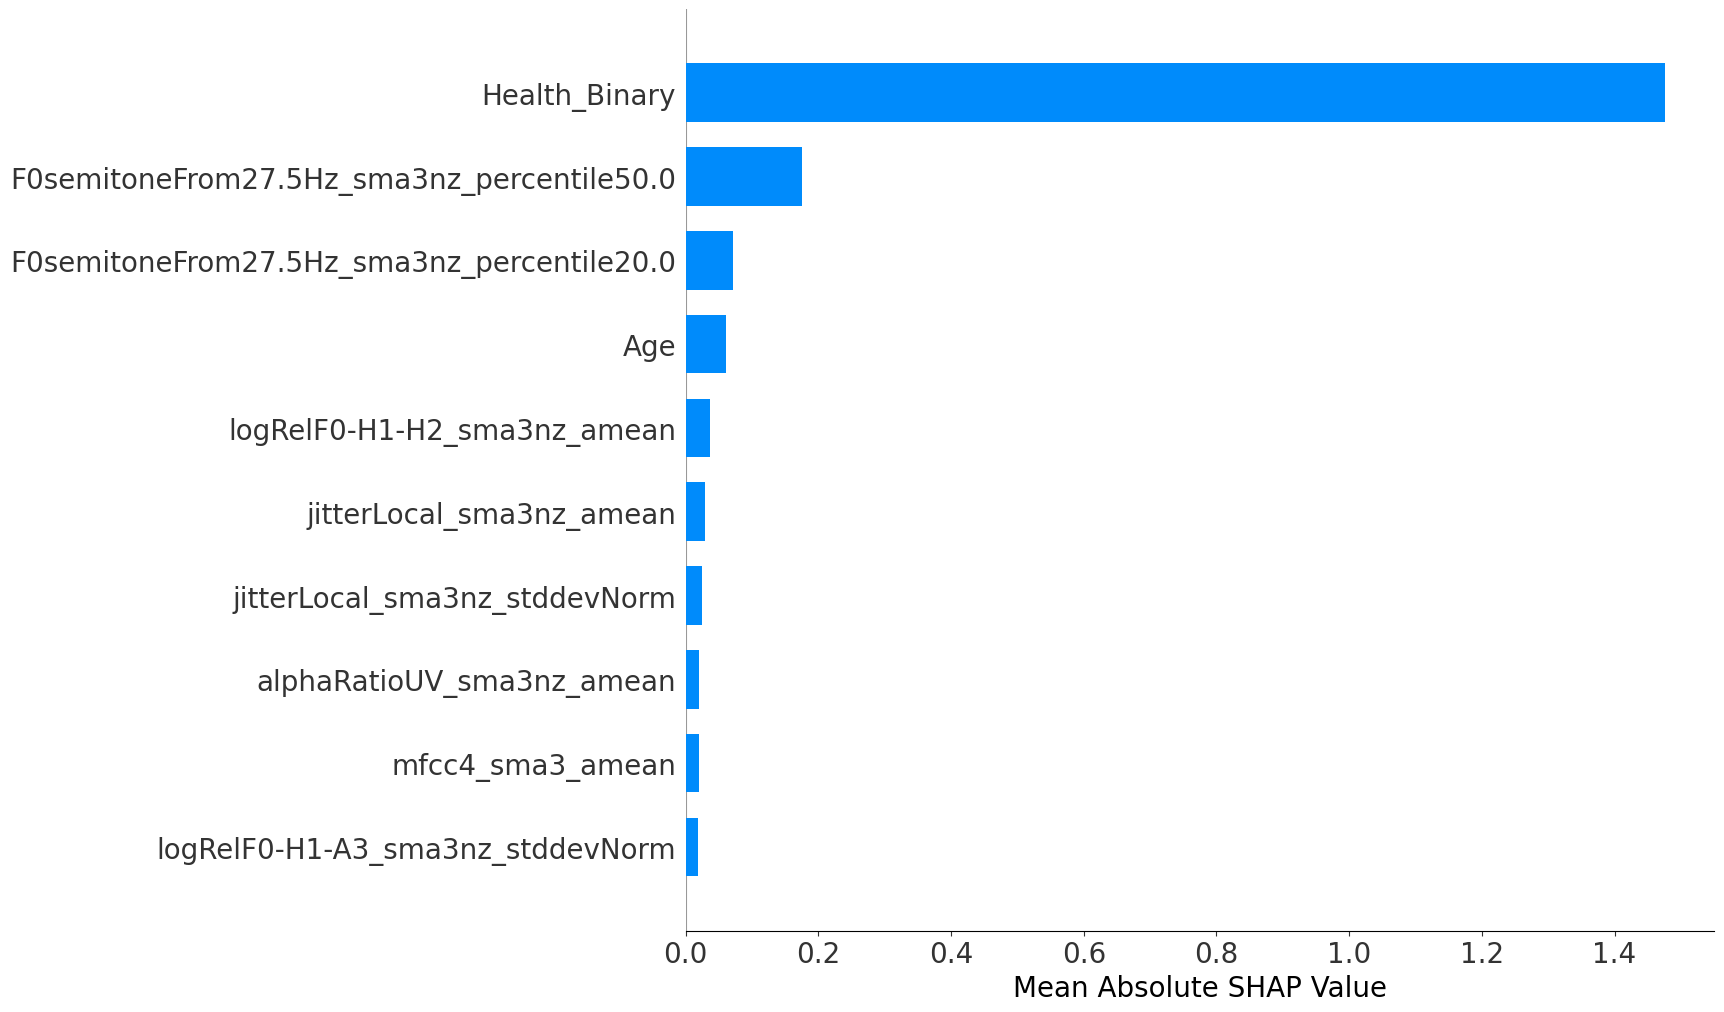

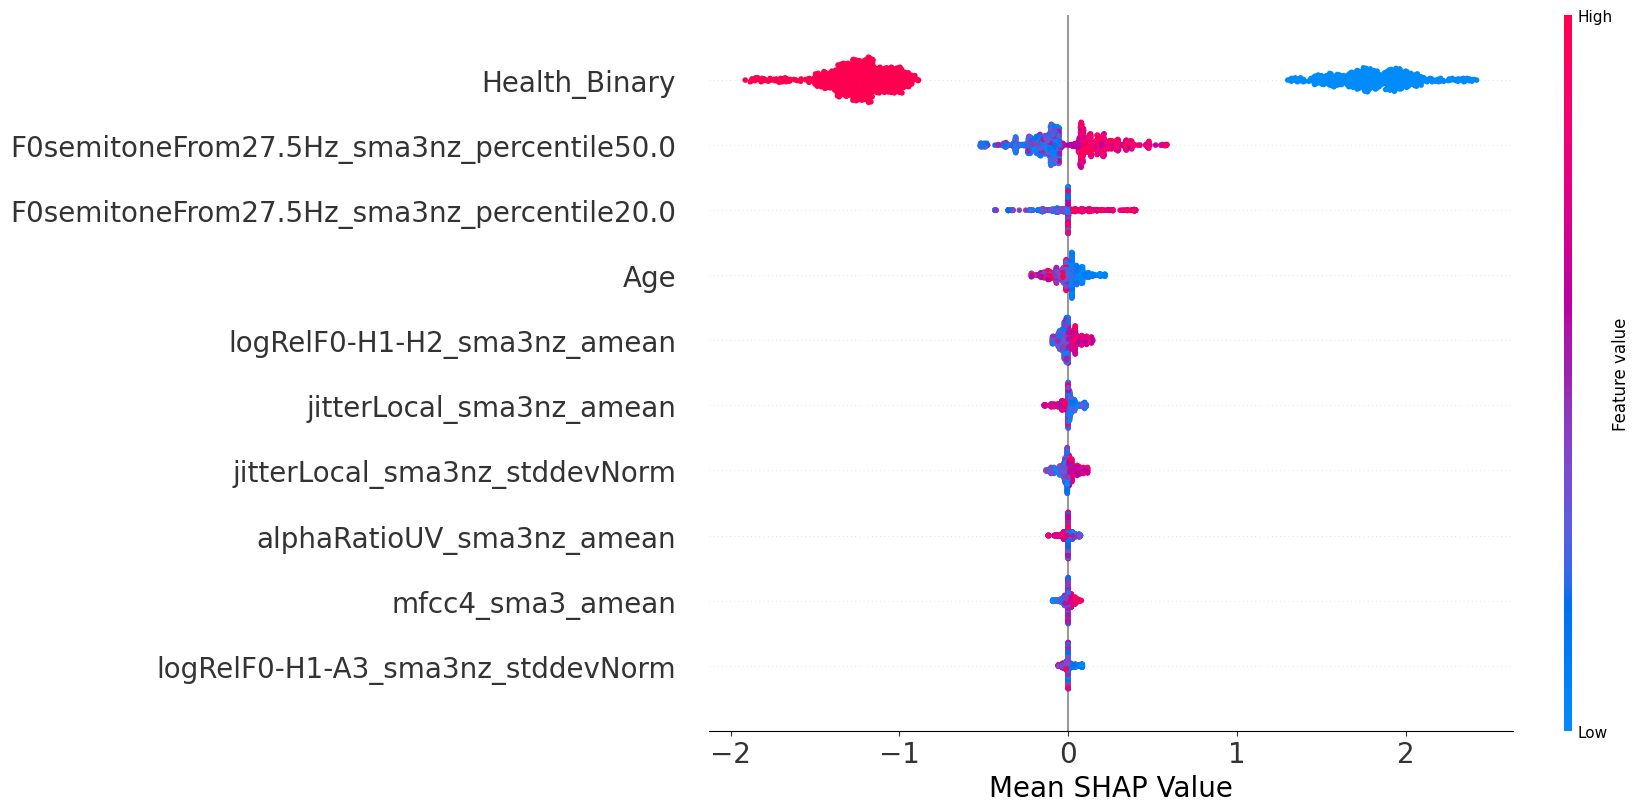

In [22]:
import matplotlib.pyplot as plt
os.makedirs(config["out_dir"], exist_ok=True)
X_shap = X.loc[shap_df_avg.index]

# Bar plot
fig = shap.summary_plot(
    shap_df_avg.values,
    X_shap,
    plot_type="bar",
    show=False,
    max_display=10,
    plot_size=(15, 10)
)
ax = plt.gca()
ax.set_xlabel("Mean Absolute SHAP Value", fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.setp(ax.get_xticklabels(), fontsize=20)
plt.setp(ax.get_yticklabels(), fontsize=20)
plt.show()
# plt.savefig(f"{config['out_dir']}/SHAP_summary_bar_plot_{config['model_name']}.png", bbox_inches='tight')
# plt.close()

# Dot plot
fig = shap.summary_plot(
    shap_df_avg.values,
    X_shap,
    plot_type="dot",
    show=False,
    max_display=10,
    plot_size=(15, 8)
)
ax = plt.gca()
ax.set_xlabel("Mean SHAP Value", fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.setp(ax.get_xticklabels(), fontsize=20)
plt.setp(ax.get_yticklabels(), fontsize=20)
plt.show()
# plt.savefig(f"{config['out_dir']}/SHAP_summary_dot_plot_{config['model_name']}.png", bbox_inches='tight')
# plt.close()

In [ ]:
def save_and_plot_gad_predictions(outer_splits, results, X, y, groups, config):
    """Save and plot out-of-sample GAD predictions from outer CV folds."""
    if config["prediction_task"] != "regression":
        return None

    rows = []
    n_outer = config["outer_splits"]

    for fold_idx, ((train_idx, val_idx), search_estimator) in enumerate(
        zip(outer_splits, results["estimator"])
    ):
        X_val = X.iloc[val_idx]
        y_true = y.iloc[val_idx].to_numpy()
        y_pred = search_estimator.predict(X_val)

        fold_df = pd.DataFrame({
            "repeat": (fold_idx // n_outer) + 1,
            "outer_fold": (fold_idx % n_outer) + 1,
            "sample_index": X.index[val_idx],
            "SessionID": np.asarray(groups)[val_idx],
            "gad_true": y_true,
            "gad_pred": y_pred,
            "residual": y_pred - y_true,
        })
        rows.append(fold_df)

    pred_df = pd.concat(rows, ignore_index=True)
    pred_df.to_csv(f"{config['out_dir']}/gad_outer_predictions.csv", index=False)

    avg_pred_df = (
        pred_df
        .groupby(["sample_index", "SessionID"], as_index=False)
        .agg(
            gad_true=("gad_true", "first"),
            gad_pred=("gad_pred", "mean"),
            gad_pred_std=("gad_pred", "std"),
            n_predictions=("gad_pred", "size"),
        )
    )
    avg_pred_df["residual"] = avg_pred_df["gad_pred"] - avg_pred_df["gad_true"]
    avg_pred_df.to_csv(f"{config['out_dir']}/gad_outer_predictions_avg.csv", index=False)

    _plot_gad_prediction_scatter(
        pred_df,
        config,
        filename="gad_prediction_vs_truth_all_outer_predictions.png",
    )

    _plot_gad_prediction_scatter(
        avg_pred_df,
        config,
        filename="gad_prediction_vs_truth_average_prediction.png",
    )

    return pred_df, avg_pred_df

def _plot_gad_prediction_scatter(pred_df, config, filename):
    y_true = pred_df["gad_true"].to_numpy()
    y_pred = pred_df["gad_pred"].to_numpy()

    residual = y_pred - y_true
    rmse = np.sqrt(np.mean(residual ** 2))
    mae = np.mean(np.abs(residual))
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    pad = max((hi - lo) * 0.05, 1)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(y_true, y_pred, alpha=0.45, s=28, edgecolor="none")
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="black", linewidth=1.5)

    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("GAD Ground Truth")
    ax.set_ylabel("GAD Prediction")
    ax.text(
        0.05,
        0.95,
        f"RMSE = {rmse:.2f}\nMAE = {mae:.2f}\nR2 = {r2:.2f}",
        transform=ax.transAxes,
        va="top",
    )

    fig.tight_layout()
    # fig.savefig(f"{config['out_dir']}/{filename}", dpi=300, bbox_inches="tight")
    # plt.close(fig)

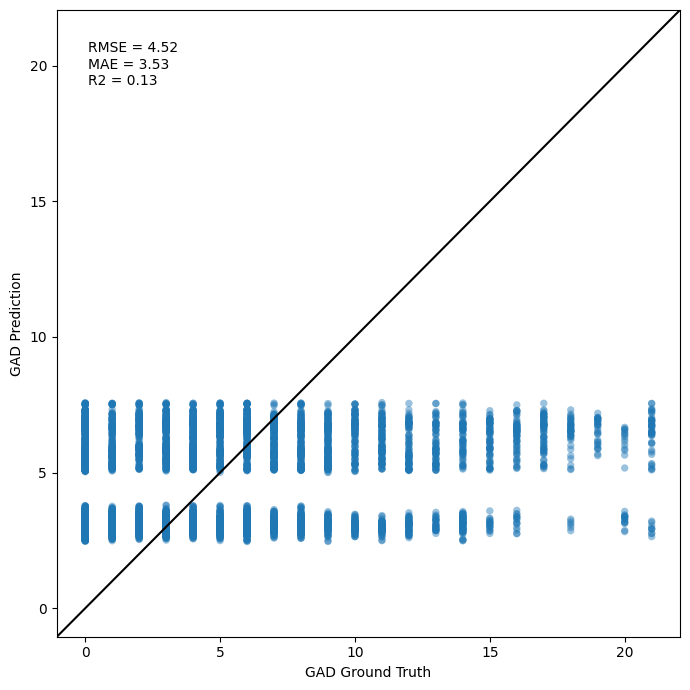

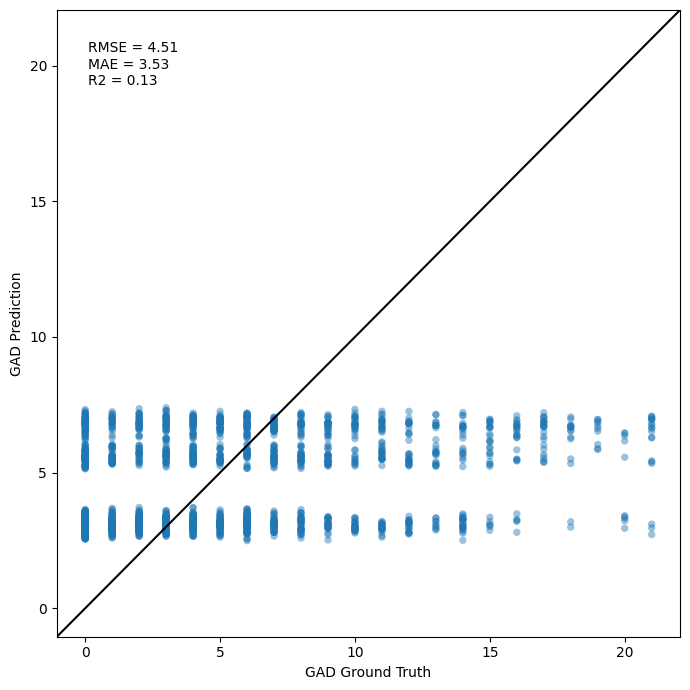

In [62]:
pred_df, avg_pred_df = save_and_plot_gad_predictions(
    outer_splits=outer_splits,
    results=results,
    X=X,
    y=y,
    groups=groups,
    config=config,
)